In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
# Load dataset
file_path = "/content/StressLevelDataset.csv"
df = pd.read_csv(file_path)
print(df.head())

   anxiety_level  self_esteem  mental_health_history  depression  headache  \
0             14           20                      0          11         2   
1             15            8                      1          15         5   
2             12           18                      1          14         2   
3             16           12                      1          15         4   
4             16           28                      0           7         2   

   blood_pressure  sleep_quality  breathing_problem  noise_level  \
0               1              2                  4            2   
1               3              1                  4            3   
2               1              2                  2            2   
3               3              1                  3            4   
4               3              5                  1            3   

   living_conditions  ...  basic_needs  academic_performance  study_load  \
0                  3  ...            2        

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

In [5]:
df.isnull().sum()


,0
anxiety_level,0
self_esteem,0
mental_health_history,0
depression,0
headache,0
blood_pressure,0
sleep_quality,0
breathing_problem,0
noise_level,0
living_conditions,0


In [6]:
df.describe()


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


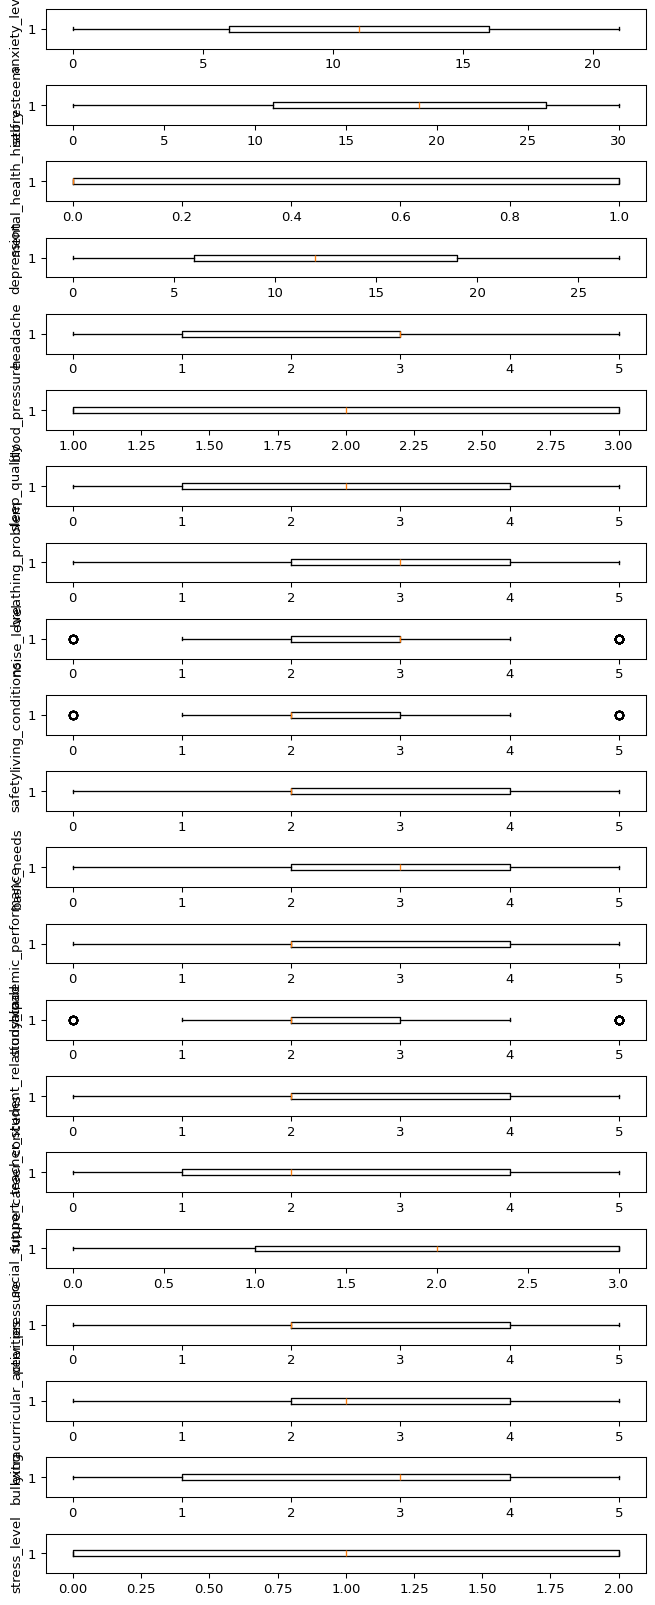

In [7]:
# Box Plots
fig, axs = plt.subplots(nrows=len(df.columns), ncols=1, dpi=95, figsize=(7, 17))

for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


In [8]:
# Remove outliers using IQR method for multiple columns
def remove_outliers(df, column, factor=1.5):
    q1, q3 = np.percentile(df[column], [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

columns_to_filter = ['anxiety_level', 'self_esteem', 'depression', 'blood_pressure',
                     'sleep_quality', 'noise_level', 'study_load', 'peer_pressure']

for col in columns_to_filter:
    df = remove_outliers(df, col)



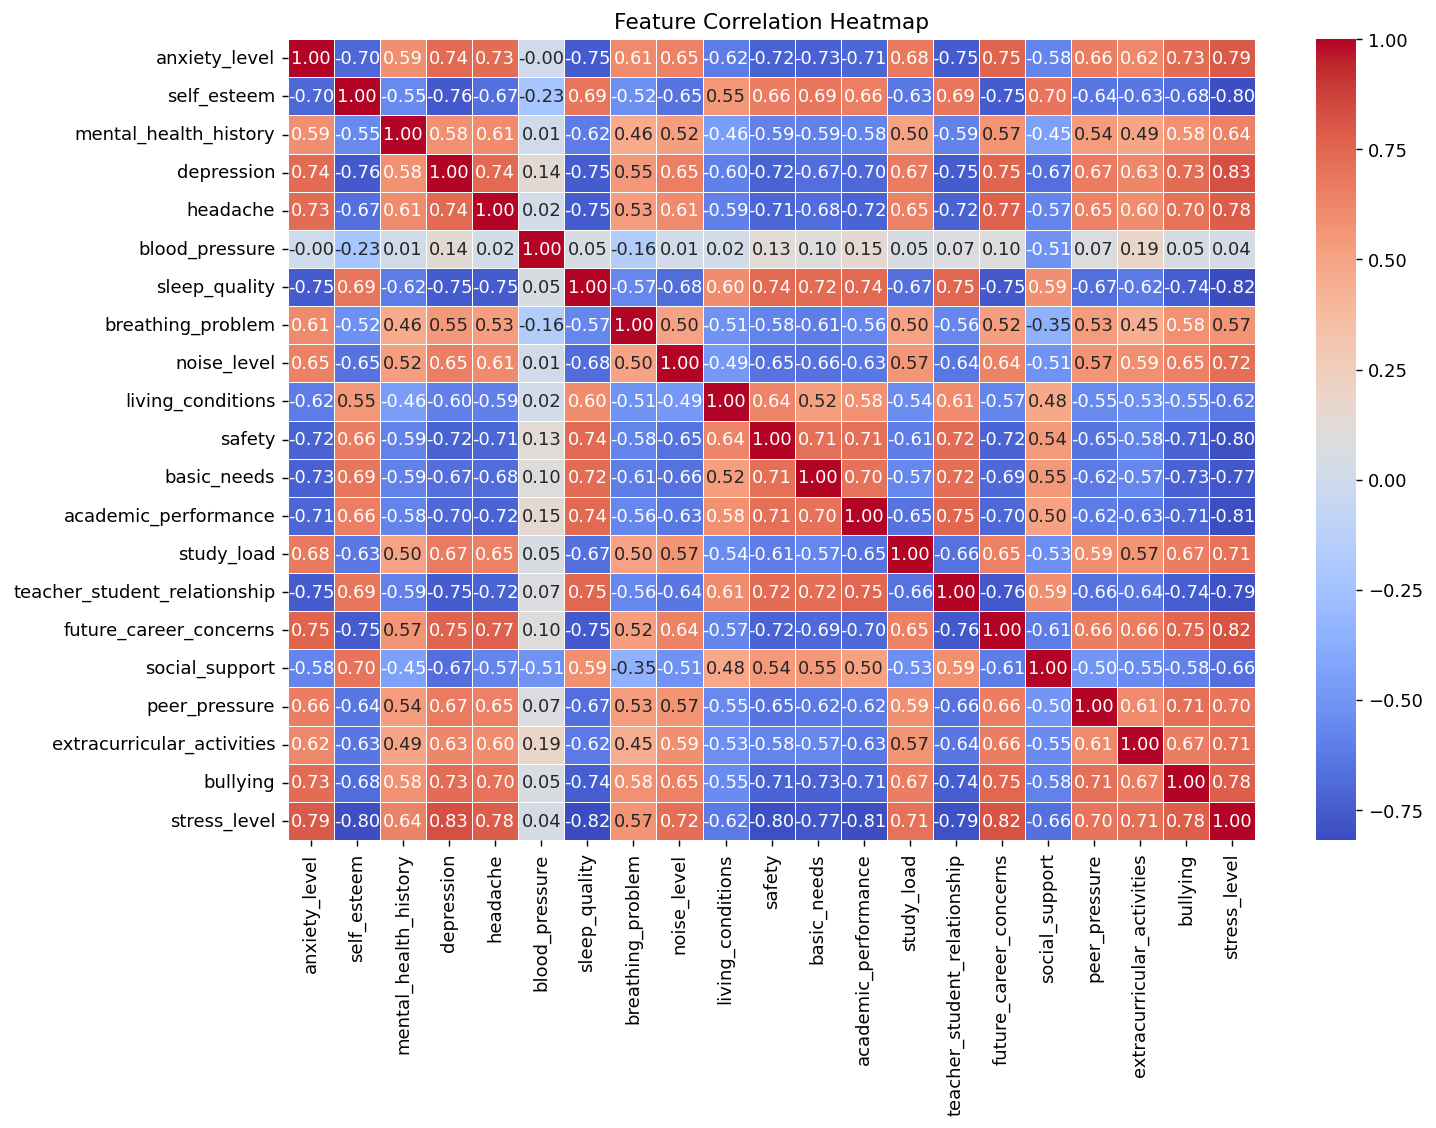

In [9]:
# Correlation heatmap
plt.figure(figsize=(12, 8), dpi=130)
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


In [10]:
# Display correlation of all features with stress_level
corr = df.corr()
print(corr['stress_level'].sort_values(ascending=False))




stress_level                    1.000000
depression                      0.825359
future_career_concerns          0.815071
anxiety_level                   0.787000
headache                        0.784039
bullying                        0.778193
noise_level                     0.717208
extracurricular_activities      0.710796
study_load                      0.708565
peer_pressure                   0.696500
mental_health_history           0.641023
breathing_problem               0.571144
blood_pressure                  0.038147
living_conditions              -0.622369
social_support                 -0.664946
basic_needs                    -0.772918
teacher_student_relationship   -0.793651
safety                         -0.801552
self_esteem                    -0.804549
academic_performance           -0.807668
sleep_quality                  -0.818264
Name: stress_level, dtype: float64


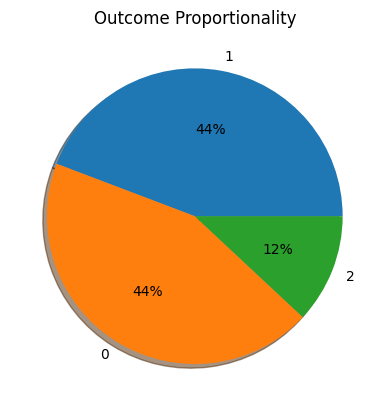

In [11]:
# Get value counts of stress_level
stress_counts = df['stress_level'].value_counts()

# Generate labels dynamically
labels = stress_counts.index.astype(str)  # Convert labels to string if needed

# Plot pie chart
plt.pie(stress_counts, labels=labels, autopct='%.f%%', shadow=True)
plt.title('Outcome Proportionality')
plt.show()


In [12]:
# separate array into input and output components
X = df.drop(columns =['stress_level'])
Y = df.stress_level


In [13]:
# initialising the MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# learning the statistical parameters for each of the data and transforming
rescaledX = scaler.fit_transform(X)
rescaledX[:5]


array([[0.66666667, 0.66666667, 0.        , 0.40740741, 0.4       ,
        0.        , 0.4       , 0.8       , 0.33333333, 0.6       ,
        0.6       , 0.4       , 0.6       , 0.33333333, 0.6       ,
        0.6       , 0.66666667, 0.66666667, 0.6       , 0.4       ],
       [0.71428571, 0.26666667, 1.        , 0.55555556, 1.        ,
        1.        , 0.2       , 0.8       , 0.66666667, 0.2       ,
        0.4       , 0.4       , 0.2       , 1.        , 0.2       ,
        1.        , 0.33333333, 1.        , 1.        , 1.        ],
       [0.57142857, 0.6       , 1.        , 0.51851852, 0.4       ,
        0.        , 0.4       , 0.4       , 0.33333333, 0.4       ,
        0.6       , 0.4       , 0.4       , 0.66666667, 0.6       ,
        0.4       , 0.66666667, 0.66666667, 0.4       , 0.4       ],
       [0.76190476, 0.4       , 1.        , 0.55555556, 0.8       ,
        1.        , 0.2       , 0.6       , 1.        , 0.4       ,
        0.4       , 0.4       , 0.4       , 1

In [14]:
# Load the dataset
df = pd.read_csv("/content/StressLevelDataset.csv")
print(df.head())


   anxiety_level  self_esteem  mental_health_history  depression  headache  \
0             14           20                      0          11         2   
1             15            8                      1          15         5   
2             12           18                      1          14         2   
3             16           12                      1          15         4   
4             16           28                      0           7         2   

   blood_pressure  sleep_quality  breathing_problem  noise_level  \
0               1              2                  4            2   
1               3              1                  4            3   
2               1              2                  2            2   
3               3              1                  3            4   
4               3              5                  1            3   

   living_conditions  ...  basic_needs  academic_performance  study_load  \
0                  3  ...            2        

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X)
rescaledX = scaler.transform(X)
rescaledX[:5]


array([[ 9.54248316e-01, -2.17990329e-01, -7.25630263e-01,
         2.23419080e-01,  1.23831817e-03, -1.03826958e+00,
        -8.66937192e-01,  1.31801971e+00, -2.04814419e-01,
         1.71586369e-01, -1.94577008e-01, -9.64748590e-01,
        -2.07528973e-01, -2.07826765e-01, -1.56710938e-01,
         8.13067794e-01, -5.12511830e-01,  9.07285583e-01,
         6.61812205e-01, -6.12813922e-02],
       [ 1.14520421e+00, -1.91395116e+00,  1.37811231e+00,
         8.69850946e-01,  2.67229060e+00,  1.73688220e+00,
        -1.60723154e+00,  1.31801971e+00,  9.45666577e-01,
        -1.99281011e+00, -9.80536946e-01, -9.64748590e-01,
        -1.77819562e+00,  2.10887779e+00, -1.74368508e+00,
         2.51000754e+00, -1.68981536e+00,  2.02621926e+00,
         2.48147942e+00,  2.38656977e+00],
       [ 5.72336521e-01, -5.00650468e-01,  1.37811231e+00,
         7.08242980e-01,  1.23831817e-03, -1.03826958e+00,
        -8.66937192e-01, -3.41623322e-01, -2.04814419e-01,
        -9.10611870e-01, -1.9

In [16]:
# Define features and target variable
X = df.drop(columns=['stress_level'])  # Features
y = df['stress_level']  # Target variable

In [17]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Initialize the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [19]:
# Train the model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
# Make predictions on the test set
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)

# Evaluate the model
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[68  4  4]
 [ 6 63  4]
 [ 7  3 61]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.87        76
           1       0.90      0.86      0.88        73
           2       0.88      0.86      0.87        71

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220



In [21]:
# Example of making predictions
sample_data = X_test.iloc[0]  # Take a sample from the test set
sample_prediction = model.predict([sample_data])
print(f"Predicted Stress Level: {sample_prediction[0]}")

Predicted Stress Level: 2


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
sample_input = {
    'anxiety_level': 14,
    'self_esteem': 20,
    'mental_health_history': 0,
    'depression': 11,
    'headache': 2,
    'blood_pressure': 1,
    'sleep_quality': 2,
    'breathing_problem': 4,
    'noise_level': 2,
    'living_conditions': 3,
    'safety': 3,
    'basic_needs': 2,
    'academic_performance': 3,
    'study_load': 2,
    'teacher_student_relationship': 3,
    'future_career_concerns': 3,
    'social_support': 2,
    'peer_pressure': 3,
    'extracurricular_activities': 3,
    'bullying': 2
}

# Convert the sample input to a DataFrame
sample_df = pd.DataFrame([sample_input])

# Step 5: Make predictions using the trained model
predicted_stress_level = model.predict(sample_df)

# Display the prediction
print(f"Predicted Stress Level: {predicted_stress_level[0]}")

Predicted Stress Level: 1


In [ ]:
from sklearn.linear_model import LogisticRegression
# Define features and target variable
X = df.drop(columns=['stress_level'])  # Features
y = df['stress_level']  # Target variable

# Train the Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

# Evaluate the Model
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Example of making predictions with a sample input
sample_input = {
    'anxiety_level': 14,
    'self_esteem': 20,
    'mental_health_history': 0,
    'depression': 11,
    'headache': 2,
    'blood_pressure': 1,
    'sleep_quality': 2,
    'breathing_problem': 4,
    'noise_level': 2,
    'living_conditions': 3,
    'safety': 3,
    'basic_needs': 2,
    'academic_performance': 3,
    'study_load': 2,
    'teacher_student_relationship': 3,
    'future_career_concerns': 3,
    'social_support': 2,
    'peer_pressure': 3,
    'extracurricular_activities': 3,
    'bullying': 2
}

# Convert the sample input to a DataFrame
sample_df = pd.DataFrame([sample_input])

# Make predictions using the trained model
predicted_stress_level = model.predict(sample_df)

# Display the prediction
print(f"Predicted Stress Level: {predicted_stress_level[0]}")


[[66  6  4]
 [ 6 65  2]
 [ 4  3 64]]
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        76
           1       0.88      0.89      0.88        73
           2       0.91      0.90      0.91        71

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220

Predicted Stress Level: 1


In [ ]:
# Example of making predictions
sample_data = X_test.iloc[0]  # Take a sample from the test set
sample_prediction = model.predict([sample_data])
print(f"Predicted Stress Level: {sample_prediction[0]}")


Predicted Stress Level: 2


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
from xgboost import XGBClassifier

# Initialize and train XGBoost model
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)


Accuracy: 0.98
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        57
           1       0.99      0.97      0.98        71
           2       0.94      0.94      0.94        16

    accuracy                           0.98       144
   macro avg       0.97      0.97      0.97       144
weighted avg       0.98      0.98      0.98       144



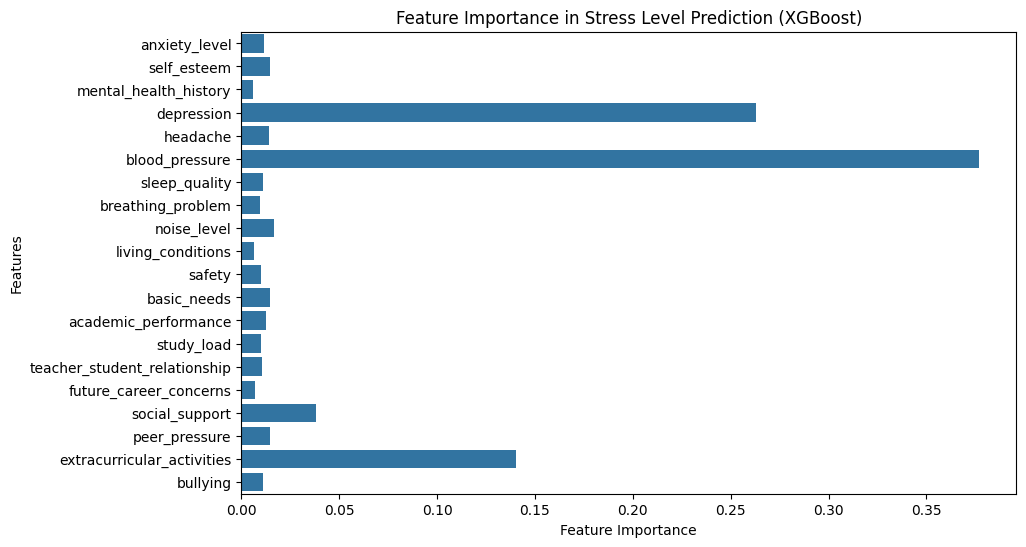

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Load dataset
file_path = "/content/StressLevelDataset.csv"
df = pd.read_csv(file_path)

# Remove outliers using IQR method
def remove_outliers(df, column, factor=1.5):
    q1, q3 = np.percentile(df[column], [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

columns_to_filter = ['anxiety_level', 'self_esteem', 'depression', 'blood_pressure',
                     'sleep_quality', 'noise_level', 'study_load', 'peer_pressure']

for col in columns_to_filter:
    df = remove_outliers(df, col)

# Separate features and target
X = df.drop(columns=['stress_level'])  # Adjust column name as per dataset
y = df['stress_level']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train XGBoost model
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", report)

# Feature importance visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_model.feature_importances_, y=X.columns)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance in Stress Level Prediction (XGBoost)")
plt.show()
